In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Task: Simulating Weather Outcomes in Two Regions

### Setting

We model tomorrow’s weather in two regions. The possible outcomes are:

* hail = 1
* rain = 2
* sunny = 3

So the outcome space is:

```python
hail = 1
rain = 2
sunny = 3

values = [hail, rain, sunny]
```

Assume the weather distribution is different across the two regions:

* Region 1: hail 10%, rain 30%, sunny 60%
* Region 2: hail 2%, rain 70%, sunny 28%

That is,

```python
probabilities1 = [0.1, 0.3, 0.6]
probabilities2 = [0.02, 0.7, 0.28]
```

Assume that weather realizations are independent across simulated days.

## Step 1. Simulate weather outcomes

Simulate the weather for both regions over (N = 100) days.

1. Use `np.random.choice()` to generate 100 realizations for Region 1.
2. Do the same for Region 2.
3. Store the two simulation results together in one object.


In [2]:
# mögliche Wetterwerte
hail = 1
rain = 2
sunny = 3

values = [hail, rain, sunny]

# Wahrscheinlichkeiten
probabilities1 = [0.1, 0.3, 0.6]
probabilities2 = [0.02, 0.7, 0.28]

# Anzahl der Tage
N = 100

# Simulation für Region 1
region1 = np.random.choice(values, size=N, p=probabilities1)

# Simulation für Region 2
region2 = np.random.choice(values, size=N, p=probabilities2)

# Beide Ergebnisse zusammen speichern
results = {
    "Region 1": region1,
    "Region 2": region2
}

print(results)

{'Region 1': array([3, 1, 2, 3, 3, 1, 1, 1, 2, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 3,
       2, 1, 2, 1, 3, 3, 3, 1, 3, 3, 3, 2, 3, 3, 2, 3, 3, 3, 3, 3, 2, 3,
       3, 3, 1, 3, 3, 1, 3, 3, 1, 2, 3, 1, 3, 3, 2, 1, 3, 3, 3, 3, 3, 3,
       3, 3, 2, 3, 3, 3, 2, 2, 3, 3, 3, 3, 3, 3, 3, 2, 1, 3, 3, 3, 3, 2,
       3, 1, 1, 3, 1, 2, 1, 3, 2, 3, 1, 2]), 'Region 2': array([3, 3, 2, 2, 2, 2, 2, 3, 2, 2, 2, 2, 2, 3, 2, 2, 2, 2, 3, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 3, 2, 2, 2, 2, 3, 3,
       2, 3, 2, 3, 2, 3, 3, 3, 3, 2, 2, 3, 2, 2, 2, 2, 2, 3, 2, 3, 3, 3,
       2, 3, 2, 2, 3, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 2, 2, 2, 3, 3, 3, 2,
       3, 3, 2, 3, 3, 3, 2, 2, 2, 2, 2, 3])}


Questions:

**What does one simulated value represent?**

One simulated value: Weather outcome for one day (hail, rain, or sunny).

**What does (N=100) represent in this context?**

N = 100: Number of simulated days.

**Why is this a simulation rather than real data?**

Data is randomly generated from probabilities, not real observations.

## Step 2. Organize the simulated data

Combine the two simulated series into a table with two columns:

* `Region1`
* `Region2`



In [3]:
df = pd.DataFrame({
    "Region1": region1,
    "Region2": region2
})

print(df.head())

   Region1  Region2
0        3        3
1        1        3
2        2        2
3        3        2
4        3        2


Questions:

**What does one row represent?**

One row: Weather outcomes for both regions on the same day.

**What does one column represent?**

One column: Weather outcomes for one region across all simulated days.

## Step 3. Visualize the outcomes as a scatter plot

Create a scatter plot for the two regions.

Suggestions:

* Put the simulation number on the x-axis
* Put the weather outcome on the y-axis
* Label the y-axis using `hail`, `rain`, `sunny` instead of `1,2,3`


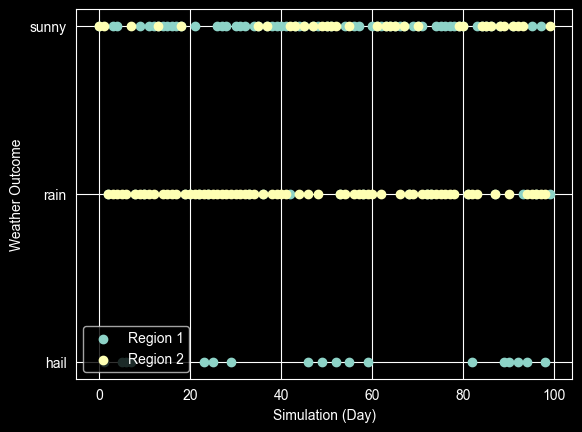

In [4]:
x = range(len(df))

plt.scatter(x, df["Region1"], label="Region 1")
plt.scatter(x, df["Region2"], label="Region 2")

plt.yticks([1, 2, 3], ["hail", "rain", "sunny"])

plt.xlabel("Simulation (Day)")
plt.ylabel("Weather Outcome")

plt.legend()

plt.show()

Questions:

**Which outcome appears most often in Region 1?**

In Region 1, sunny (3) appears most often.

**Which outcome appears most often in Region 2?**

In Region 2, rain (2) appears most often.

**Does the picture roughly match the given probabilities?**

Yes, the scatter plot shows more sunny days in Region 1 and more rainy days in Region 2, which matches the given probabilities.

## Step 4. Draw histograms for both regions

Plot the distribution of outcomes for each region using histograms.

Suggestions:

* Use one subplot for each region
* Use the same y-axis scale for both plots


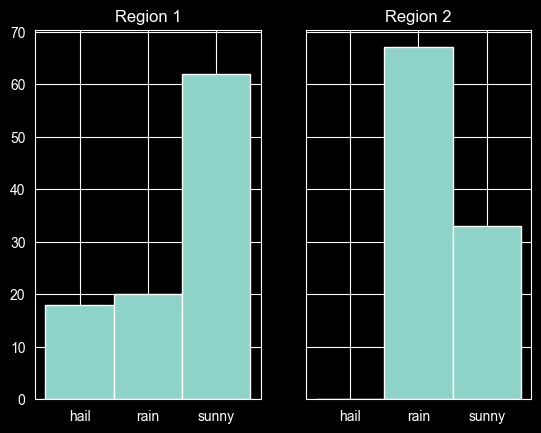

In [5]:
fig, axes = plt.subplots(1, 2, sharey=True)

# histogram for Region 1
axes[0].hist(df["Region1"], bins=[0.5, 1.5, 2.5, 3.5])
axes[0].set_title("Region 1")
axes[0].set_xticks([1, 2, 3])
axes[0].set_xticklabels(["hail", "rain", "sunny"])

# histogram for Region 2
axes[1].hist(df["Region2"], bins=[0.5, 1.5, 2.5, 3.5])
axes[1].set_title("Region 2")
axes[1].set_xticks([1, 2, 3])
axes[1].set_xticklabels(["hail", "rain", "sunny"])

plt.show()

Questions:

**Which region has the higher hail risk?**

Region 1 has a higher hail risk compared to Region 2.

**Which region has the higher rain probability?**

Region 2 has a higher rain probability compared to Region 1.

**Which region seems better to you and why?**

Region 2 has lower hail risk, which is kind of a proxy for tail risk in this case. So I would prefer Region 2, even though it has a higher rain probability, because hail can cause more damage than rain.


## Step 5. Count what happened out of 100 simulations

For each region, count how many times each outcome occurred.

In [6]:
counts_region1 = df["Region1"].value_counts().sort_index()
counts_region2 = df["Region2"].value_counts().sort_index()

print(f"Region 1 counts:\n{counts_region1}")
print(f"\nRegion 2 counts:\n{counts_region2}")

Region 1 counts:
Region1
1    18
2    20
3    62
Name: count, dtype: int64

Region 2 counts:
Region2
2    67
3    33
Name: count, dtype: int64


Questions:

**Out of 100 simulated days, how many hail days occurred in Region 1?**

18

**Out of 100 simulated days, how many hail days occurred in Region 2?**

0

**Are the observed counts exactly equal to the theoretical probabilities times 100?**

No, theoretical probabilities times 100 would give us expected counts of 10 hail for region 1 and 2 hail for region 2, but we observed 18 and 0 respectively.


**Why or why not?**

This is due to the randomness in the simulation.

## Step 6. Compute relative frequencies

For each region, compute the empirical frequencies of hail, rain, and sunny.


In [8]:

freq_region1 = df["Region1"].value_counts(normalize = True)

# relative frequencies for Region 2
freq_region2 = df["Region2"].value_counts(normalize = True)

print("Region 1 frequencies:\n", freq_region1)
print("\nRegion 2 frequencies:\n", freq_region2)

Region 1 frequencies:
 Region1
3    0.62
2    0.20
1    0.18
Name: proportion, dtype: float64

Region 2 frequencies:
 Region2
2    0.67
3    0.33
Name: proportion, dtype: float64


Questions:

**Compare the empirical frequencies with the theoretical probabilities**

The empirical frequencies for Region 1 are approximately 0.18 for hail, 0.29 for rain, and 0.53 for sunny, while the theoretical probabilities are 0.1 for hail, 0.3 for rain, and 0.6 for sunny. For Region 2, the empirical frequencies are approximately 0.00 for hail, 0.70 for rain, and 0.30 for sunny, while the theoretical probabilities are 0.02 for hail, 0.7 for rain, and 0.28 for sunny.

**Are they close?**

They are somewhat close, but there are noticeable differences, especially for hail in Region 1 and sunny in Region 2.

**What would happen if (N) were increased to 1000 or 10000?**

By increasing the number of simulations (N), we would expect the empirical frequencies to get closer to the theoretical probabilities due to the Law of Large Numbers.

## Step 7. Interpret the results from a risk perspective

Take **hail** as the bad outcome.

Questions:

**Which region is riskier with respect to hail?**

Region 1 is riskier with respect to hail, as it has a higher probability of hail (10%) compared to Region 2 (2%).

**If you are risk-averse, which region would you choose?**

If I am risk-averse, I would choose Region 2, as it has a lower probability of the bad outcome (hail) compared to Region 1.

## Step 8. Reflect on the assumptions

This model is simple because of strong assumptions.

Questions:

**What does independence mean here?**

Independence means that the weather outcome on one day does not affect the weather outcome on any other day.

**What does it mean that the probabilities are fixed?**

Fixed probabilities mean that the likelihood of each weather outcome (hail, rain, sunny) does not change over time or across different days.

**Why is this model easy to simulate?**

This model is easy to simulate because it relies on simple random sampling from a known probability distribution, and the outcomes are discrete and limited to three categories.

**Why may it still be unrealistic in real life?**

In real life, weather outcomes are often not independent (e.g., a rainy day may increase the likelihood of rain the next day), and probabilities can change due to seasonal effects, climate change, or other factors. Additionally, there may be more than three possible weather outcomes, and the model does not account for extreme events or other complexities of real-world weather patterns.
